# DBA5101 Group Project 2

## 1. Data Preparation

We first load and prepare the recycling trial dataset for analysis.

The dataset contains daily contamination rates for paper, plastic, and cans at two locations:
- **UTOWN**: treatment area
- **ENGINE**: comparison area

The trial consists of three phases:
- **Phase 1**: Baseline
- **Phase 2**: Bin-opening intervention at UTOWN
- **Phase 3**: Informational banners at UTOWN

In [69]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [70]:
DATA_PATH = os.path.join("..", "data")

In [71]:
# Load dataset
df = pd.read_excel(os.path.join(DATA_PATH, "GP2Data.xls"))

# Remove completely empty rows
df = df.dropna(how="all").copy()

# Convert phase number to int
df["FirstTrialPhase"] = df["FirstTrialPhase"].astype(int)

# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Sort observations chronologically
df = df.sort_values(["Date", "Area"]).reset_index(drop=True)

# Check cleaned dataset
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

# Show observations with missing values
print("\nRows containing missing values:")
display(df[df.isnull().any(axis=1)])

print("First few rows of dataframe:")
df.head()

Dataset shape: (85, 6)

Missing values:
Area                  0
Date                  0
PaperContaminant      0
PlasticContaminant    0
CanContaminant        2
FirstTrialPhase       0
dtype: int64

Number of duplicate rows:
0

Rows containing missing values:


,Area,Date,PaperContaminant,PlasticContaminant,CanContaminant,FirstTrialPhase
27,ENGINE,2020-02-02,0.0,0.0,NaN,1
28,UTOWN,2020-02-02,0.0,0.0,NaN,1


First few rows of dataframe:


,Area,Date,PaperContaminant,PlasticContaminant,CanContaminant,FirstTrialPhase
0,UTOWN,2020-01-13,11.222222,71.203073,46.727053,1
1,UTOWN,2020-01-14,5.888889,58.997250,43.380952,1
2,ENGINE,2020-01-15,0.714286,35.340136,0.869565,1
3,UTOWN,2020-01-15,2.888889,60.752028,40.530303,1
4,ENGINE,2020-01-16,1.142857,43.925365,17.170330,1


## 2. Contamination Rates Over Time

We plot the daily contamination rates for paper, plastic, and cans separately for UTOWN and ENGINE.

These plots provide an initial visual comparison of recycling behaviour across the three trial phases before conducting formal causal analysis.

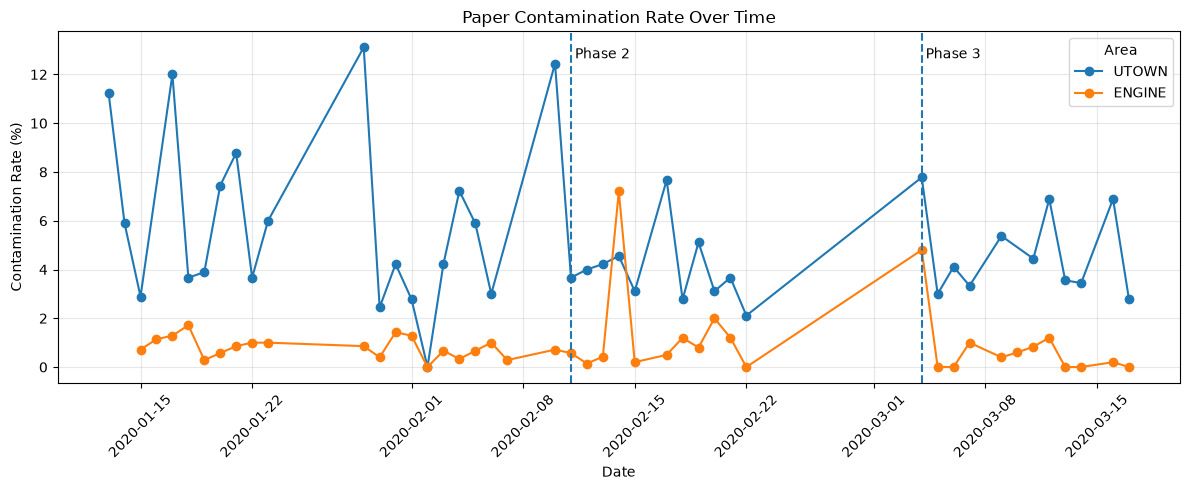

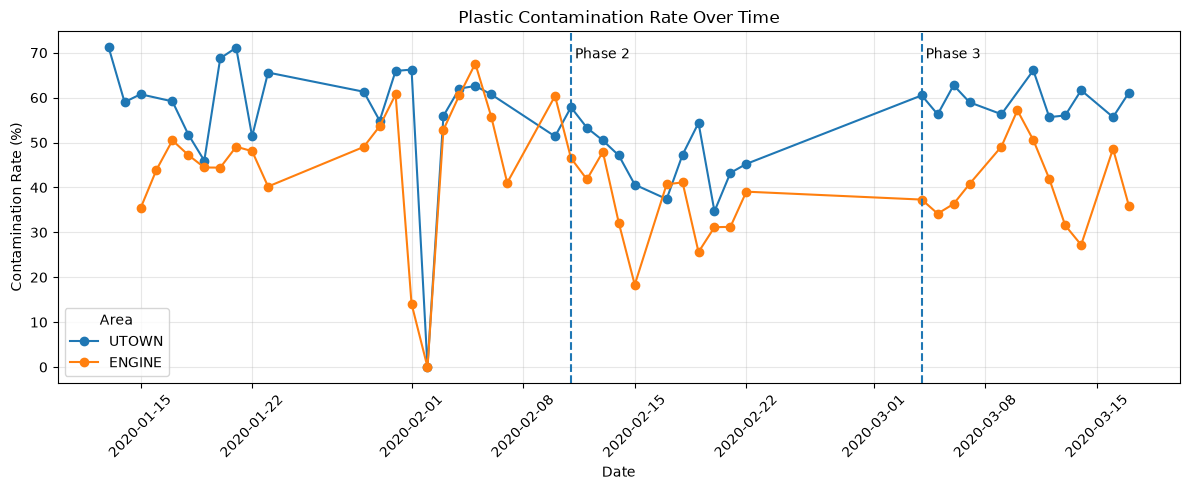

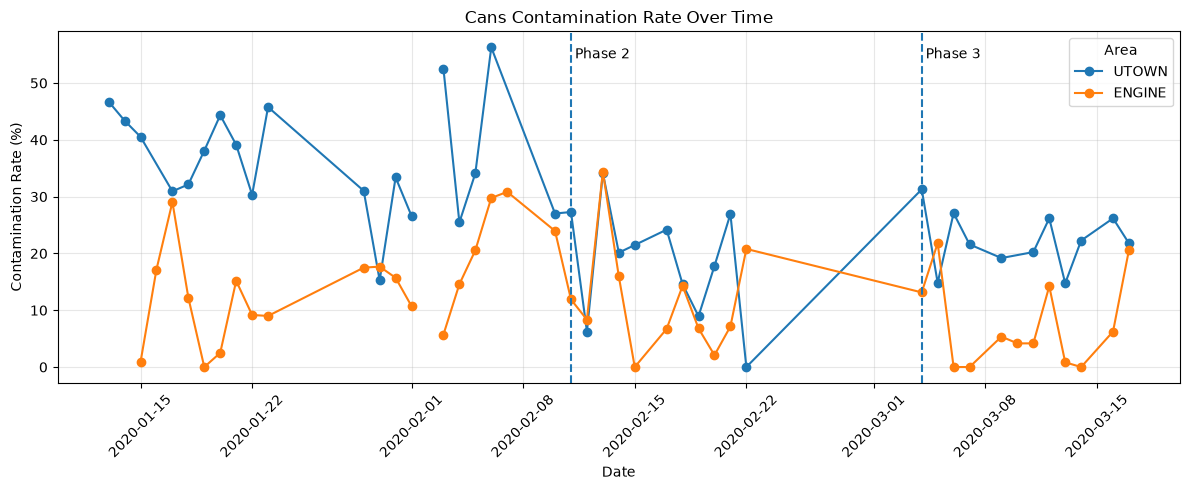

In [72]:
# Contamination variables and display names
materials = {
    "PaperContaminant": "Paper",
    "PlasticContaminant": "Plastic",
    "CanContaminant": "Cans"
}

# Phase boundaries
phase2_start = df.loc[df["FirstTrialPhase"] == 2, "Date"].min()
phase3_start = df.loc[df["FirstTrialPhase"] == 3, "Date"].min()

# Create one graph for each recyclable material
for variable, material in materials.items():

    fig, ax = plt.subplots(figsize=(12, 5))

    for area in ["UTOWN", "ENGINE"]:
        temp = df[df["Area"] == area]

        ax.plot(
            temp["Date"],
            temp[variable],
            marker="o",
            label=area
        )

    # Mark beginning of Phase 2 and Phase 3
    ax.axvline(phase2_start, linestyle="--")
    ax.axvline(phase3_start, linestyle="--")

    # Phase labels
    ymax = df[variable].max()

    ax.text(
        phase2_start,
        ymax,
        " Phase 2",
        verticalalignment="top"
    )

    ax.text(
        phase3_start,
        ymax,
        " Phase 3",
        verticalalignment="top"
    )

    ax.set_title(f"{material} Contamination Rate Over Time")
    ax.set_xlabel("Date")
    ax.set_ylabel("Contamination Rate (%)")
    ax.legend(title="Area")
    ax.grid(alpha=0.3)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Contamination Rates Over Time — Missing Values Replaced with Zero

For visualization purposes, missing contamination values are temporarily replaced with zero. The original dataset is retained unchanged for subsequent statistical analysis, since a missing observation does not necessarily represent a zero contamination rate.

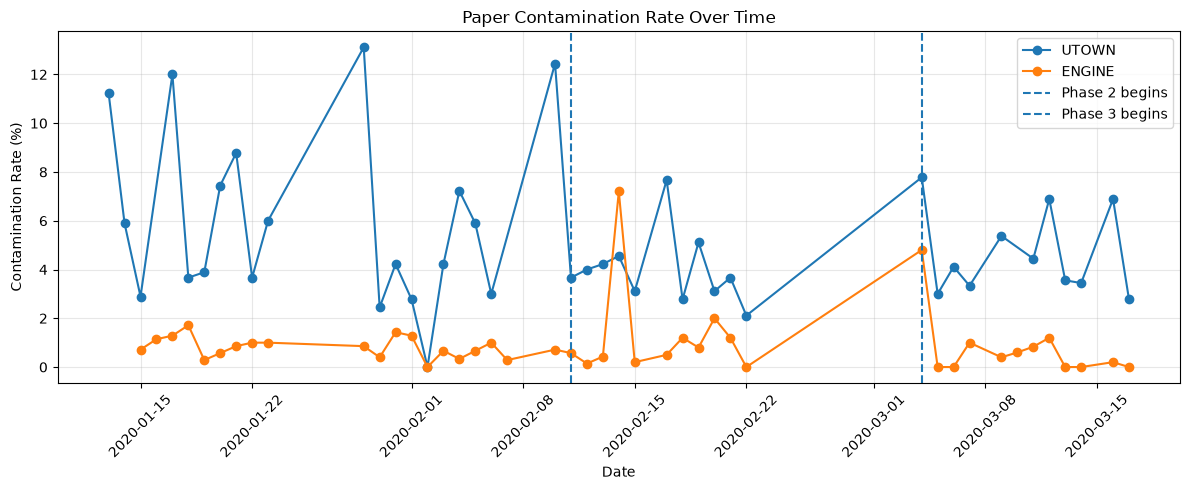

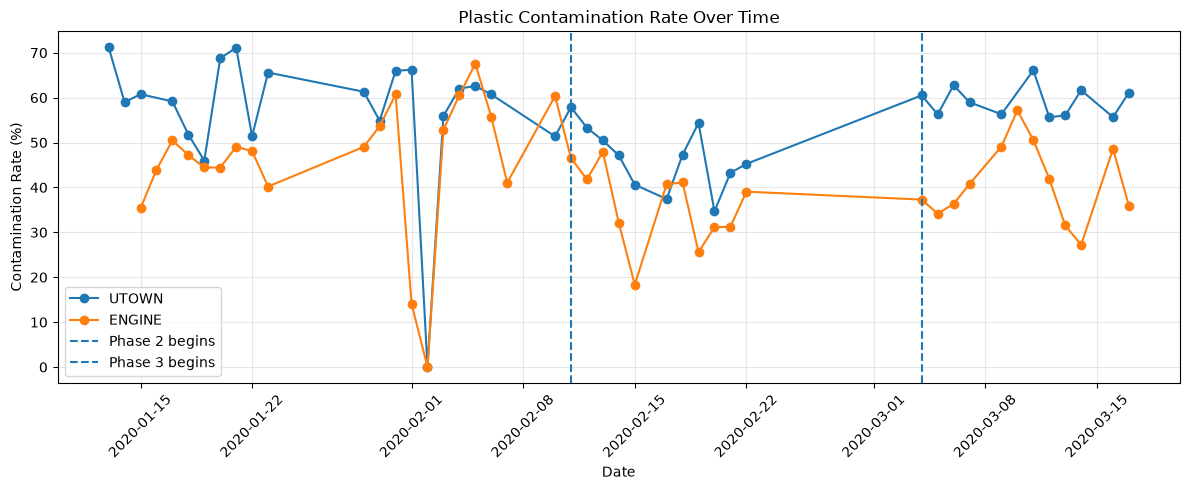

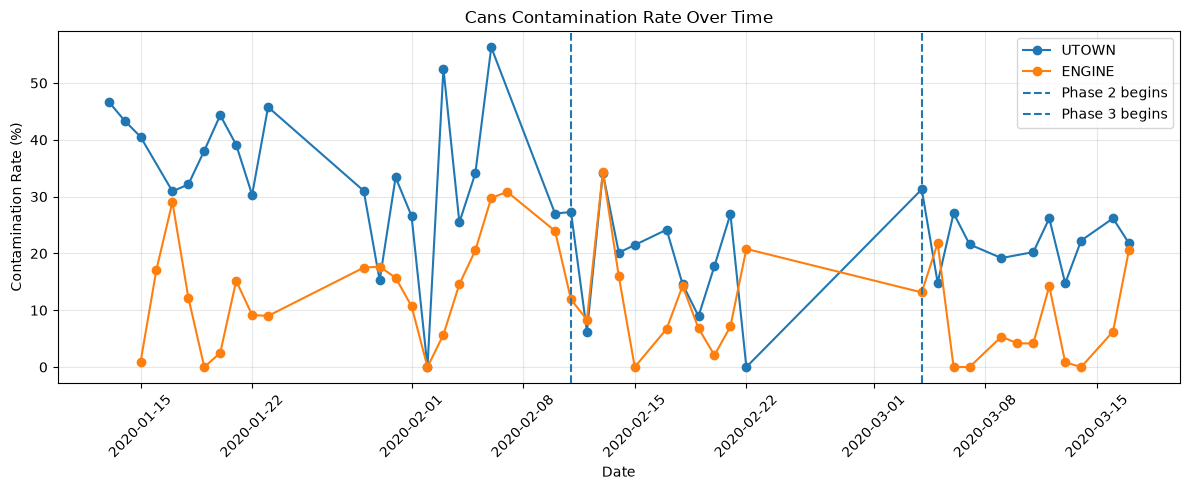

In [73]:
# Create a separate copy for visualization
df_plot = df.copy()

# Replace missing contamination values with 0 in plotting data only
contamination_vars = [
    "PaperContaminant",
    "PlasticContaminant",
    "CanContaminant"
]

df_plot[contamination_vars] = df_plot[contamination_vars].fillna(0)

# Variables to plot
materials = {
    "PaperContaminant": "Paper",
    "PlasticContaminant": "Plastic",
    "CanContaminant": "Cans"
}

# Identify start dates of Phase 2 and Phase 3
phase2_start = df_plot.loc[
    df_plot["FirstTrialPhase"] == 2, "Date"
].min()

phase3_start = df_plot.loc[
    df_plot["FirstTrialPhase"] == 3, "Date"
].min()

# Plot contamination rates over time
for variable, material in materials.items():

    fig, ax = plt.subplots(figsize=(12, 5))

    for area in ["UTOWN", "ENGINE"]:

        temp = df_plot[df_plot["Area"] == area]

        ax.plot(
            temp["Date"],
            temp[variable],
            marker="o",
            label=area
        )

    # Mark intervention phases
    ax.axvline(
        phase2_start,
        linestyle="--",
        label="Phase 2 begins"
    )

    ax.axvline(
        phase3_start,
        linestyle="--",
        label="Phase 3 begins"
    )

    ax.set_title(f"{material} Contamination Rate Over Time")
    ax.set_xlabel("Date")
    ax.set_ylabel("Contamination Rate (%)")

    ax.legend()
    ax.grid(alpha=0.3)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 3. Difference-in-Differences (DiD) Experiments

In [74]:
df.head()

,Area,Date,PaperContaminant,PlasticContaminant,CanContaminant,FirstTrialPhase
0,UTOWN,2020-01-13,11.222222,71.203073,46.727053,1
1,UTOWN,2020-01-14,5.888889,58.997250,43.380952,1
2,ENGINE,2020-01-15,0.714286,35.340136,0.869565,1
3,UTOWN,2020-01-15,2.888889,60.752028,40.530303,1
4,ENGINE,2020-01-16,1.142857,43.925365,17.170330,1


There are 2 rows with missing values, both corresponding to 2 February 2020. For each of ENGINE and UTOWN on this date, the can contamination rate is missing. Note that for both locations, the other contamination rates are exactly 0. It is unlikely for the contamination rate of a material to be exactly zero. It is more probable that there is no data obtained at both locations on 2 February 2020. For this reason, we drop these two rows. In a real-world setting, however, we would confirm this with the provider of the dataset.

In [75]:
df_processed = df.dropna(subset=["CanContaminant"])
df_processed.shape

(83, 6)

In [76]:
df_processed = df_processed.rename(columns={
    "Area": "area",
    "Date": "date",
    "PaperContaminant": "paper_rate",
    "PlasticContaminant": "plastic_rate",
    "CanContaminant": "can_rate",
    "FirstTrialPhase": "phase"
})

In [77]:
df_processed["treat"] = (df_processed["area"] == "UTOWN").astype(int)       # "Treat" variable
df_processed["is_after_phase_1"] = (df_processed["phase"] > 1).astype(int)  # "Post" variable for model 1

In [78]:
df_processed.head()

,area,date,paper_rate,plastic_rate,can_rate,phase,treat,is_after_phase_1
0,UTOWN,2020-01-13,11.222222,71.203073,46.727053,1,1,0
1,UTOWN,2020-01-14,5.888889,58.997250,43.380952,1,1,0
2,ENGINE,2020-01-15,0.714286,35.340136,0.869565,1,0,0
3,UTOWN,2020-01-15,2.888889,60.752028,40.530303,1,1,0
4,ENGINE,2020-01-16,1.142857,43.925365,17.170330,1,0,0


### Model 1: Pooled Intervention Effect

Phases 2 and 3 are combined into a single post-intervention period:

$$
Y_{itm}
=
\beta_{0m}
+\beta_{1m} \text{Treat}_i
+\beta_{2m} \text{Post}_t
+\beta_{3m}(\text{Treat}_i \times \text{Post}_t)
+\varepsilon_{itm}
$$

- $Y_{itm}$: contamination rate for area $i$ at time $t$, for material $m$.
- $m \in \{\text{Paper}, \text{Plastic}, \text{Can}\}$: recyclable material.
- $\text{Treat}_i$: treatment indicator, equal to 1 for UTOWN and 0 for ENGINE.
- $\text{Post}_t$: post indicator, equal to 1 for Phase 2 or Phase 3, and 0 otherwise.
- $\beta_{3m}$: pooled DiD treatment effect for material $m$.

We fit 3 separate regressions, one for each of the 3 materials.

#### Model 1 (Paper)

In [79]:
model1_paper = smf.ols(
    "paper_rate ~ treat * is_after_phase_1",
    data=df_processed
).fit()

In [80]:
model1_paper.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             paper_rate   R-squared:                       0.553
Model:                            OLS   Adj. R-squared:                  0.536
Method:                 Least Squares   F-statistic:                     32.52
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           8.61e-14
Time:                        14:18:48   Log-Likelihood:                -177.46
No. Observations:                  83   AIC:                             362.9
Df Residuals:                      79   BIC:                             372.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0.8531      0.483      1.768      0.081      -0.108       1.814
treat                      5.5036      0.683      8.063      0.000       4.145       6.862
is_after_phase_1           0.1589      0.652      0.244      0.808      -1.139       1.457
treat:is_after_phase_1    -2.1703      0.927     -2.341      0.022      -4.016      -0.325
==============================================================================
Omnibus:                       27.263   Durbin-Watson:                   1.904
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               44.765
Skew:                           1.328   Prob(JB):                     1.90e-10
Kurtosis:                       5.426   Cond. No.                         7.11
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Model 1 (Plastic)

In [81]:
model1_plastic = smf.ols(
    "plastic_rate ~ treat * is_after_phase_1",
    data=df_processed
).fit()

In [82]:
model1_plastic.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           plastic_rate   R-squared:                       0.440
Model:                            OLS   Adj. R-squared:                  0.418
Method:                 Least Squares   F-statistic:                     20.66
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           5.60e-10
Time:                        14:18:48   Log-Likelihood:                -300.01
No. Observations:                  83   AIC:                             608.0
Df Residuals:                      79   BIC:                             617.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 48.3541      2.113     22.885      0.000      44.148      52.560
treat                     11.9439      2.988      3.997      0.000       5.996      17.892
is_after_phase_1          -9.8307      2.855     -3.443      0.001     -15.514      -4.147
treat:is_after_phase_1     2.3774      4.059      0.586      0.560      -5.701      10.456
==============================================================================
Omnibus:                       11.298   Durbin-Watson:                   1.758
Prob(Omnibus):                  0.004   Jarque-Bera (JB):               13.188
Skew:                          -0.682   Prob(JB):                      0.00137
Kurtosis:                       4.397   Cond. No.                         7.11
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Model 1 (Can)

In [83]:
model1_can = smf.ols(
    "can_rate ~ treat * is_after_phase_1",
    data=df_processed
).fit()

In [84]:
model1_can.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               can_rate   R-squared:                       0.556
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                     32.97
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           6.39e-14
Time:                        14:18:48   Log-Likelihood:                -298.98
No. Observations:                  83   AIC:                             606.0
Df Residuals:                      79   BIC:                             615.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 14.8500      2.087      7.116      0.000      10.696      19.004
treat                     21.6249      2.951      7.327      0.000      15.750      27.499
is_after_phase_1          -5.3280      2.820     -1.889      0.063     -10.941       0.285
treat:is_after_phase_1   -10.8225      4.009     -2.700      0.008     -18.802      -2.843
==============================================================================
Omnibus:                        0.699   Durbin-Watson:                   1.850
Prob(Omnibus):                  0.705   Jarque-Bera (JB):                0.518
Skew:                           0.194   Prob(JB):                        0.772
Kurtosis:                       2.992   Cond. No.                         7.11
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

###

### Model 2: Separate Phase 2 and Phase 3 Effects (Relative to Phase 1)

We use Phase 1 as the reference period.

$$
\begin{aligned}
Y_{itm}
={}&
\beta_{0m}
+\beta_{1m} \text{Treat}_i
+\beta_{2m} \text{Phase2}_t
+\beta_{3m} \text{Phase3}_t \\
&+\beta_{4m}(\text{Treat}_i \times \text{Phase2}_t)
+\beta_{5m}(\text{Treat}_i \times \text{Phase3}_t)
+\varepsilon_{itm}
\end{aligned}
$$

where:

- $Y_{itm}$: contamination rate for area $i$ at time $t$, for material $m$.
- $m \in \{\text{Paper}, \text{Plastic}, \text{Can}\}$: recyclable material.
- $\text{Treat}_i$: treatment indicator, equal to 1 for UTOWN and 0 for ENGINE.
- $\text{Phase2}_t$: phase indicator, equal to 1 if the observation is from Phase 2, and 0 otherwise.
- $\text{Phase3}_t$: phase indicator, equal to 1 if the observation is from Phase 3, and 0 otherwise.
- $\beta_{4m}$: DiD treatment effect of the Phase 2 intervention relative to Phase 1, for material $m$.
- $\beta_{5m}$: DiD treatment effect of the Phase 3 intervention relative to Phase 1, for material $m$.

We fit 3 separate regressions, one for each of the 3 materials.

#### Model 2 (Paper)

In [85]:
model2_paper = smf.ols(
    "paper_rate ~ treat * C(phase)",
    data=df_processed
).fit()

In [86]:
model2_paper.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             paper_rate   R-squared:                       0.558
Model:                            OLS   Adj. R-squared:                  0.529
Method:                 Least Squares   F-statistic:                     19.45
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           1.80e-12
Time:                        14:18:48   Log-Likelihood:                -176.94
No. Observations:                  83   AIC:                             365.9
Df Residuals:                      77   BIC:                             380.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.8531      0.486      1.756      0.083      -0.114       1.821
C(phase)[T.2]           0.4417      0.802      0.550      0.584      -1.156       2.039
C(phase)[T.3]          -0.1004      0.781     -0.129      0.898      -1.655       1.455
treat                   5.5036      0.687      8.009      0.000       4.135       6.872
treat:C(phase)[T.2]    -2.7984      1.135     -2.466      0.016      -5.058      -0.539
treat:C(phase)[T.3]    -1.5657      1.120     -1.398      0.166      -3.795       0.664
==============================================================================
Omnibus:                       26.878   Durbin-Watson:                   1.873
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               43.914
Skew:                           1.311   Prob(JB):                     2.91e-10
Kurtosis:                       5.413   Cond. No.                         8.61
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Model 2 (Plastic)

In [87]:
model2_plastic = smf.ols(
    "plastic_rate ~ treat * C(phase)",
    data=df_processed
).fit()

In [88]:
model2_plastic.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           plastic_rate   R-squared:                       0.525
Model:                            OLS   Adj. R-squared:                  0.494
Method:                 Least Squares   F-statistic:                     17.03
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           2.63e-11
Time:                        14:18:48   Log-Likelihood:                -293.14
No. Observations:                  83   AIC:                             598.3
Df Residuals:                      77   BIC:                             612.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              48.3541      1.970     24.543      0.000      44.431      52.277
C(phase)[T.2]         -12.3962      3.254     -3.810      0.000     -18.875      -5.917
C(phase)[T.3]          -7.4790      3.167     -2.362      0.021     -13.785      -1.173
treat                  11.9439      2.786      4.287      0.000       6.396      17.492
treat:C(phase)[T.2]    -1.3943      4.601     -0.303      0.763     -10.557       7.768
treat:C(phase)[T.3]     6.3629      4.540      1.401      0.165      -2.678      15.404
==============================================================================
Omnibus:                       15.158   Durbin-Watson:                   1.960
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               24.983
Skew:                          -0.707   Prob(JB):                     3.76e-06
Kurtosis:                       5.286   Cond. No.                         8.61
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Model 2 (Can)

In [89]:
model2_can = smf.ols(
    "can_rate ~ treat * C(phase)",
    data=df_processed
).fit()

In [90]:
model2_can.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               can_rate   R-squared:                       0.568
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     20.28
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           7.39e-13
Time:                        14:18:48   Log-Likelihood:                -297.79
No. Observations:                  83   AIC:                             607.6
Df Residuals:                      77   BIC:                             622.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              14.8500      2.084      7.126      0.000      10.700      19.000
C(phase)[T.2]          -3.1754      3.441     -0.923      0.359     -10.028       3.677
C(phase)[T.3]          -7.3012      3.349     -2.180      0.032     -13.971      -0.632
treat                  21.6249      2.947      7.338      0.000      15.757      27.493
treat:C(phase)[T.2]   -14.9566      4.867     -3.073      0.003     -24.648      -5.265
treat:C(phase)[T.3]    -6.8678      4.802     -1.430      0.157     -16.430       2.695
==============================================================================
Omnibus:                        0.980   Durbin-Watson:                   1.813
Prob(Omnibus):                  0.612   Jarque-Bera (JB):                0.942
Skew:                           0.250   Prob(JB):                        0.624
Kurtosis:                       2.853   Cond. No.                         8.61
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Model 3: Separate Phase 2 and Phase 3 Effects (Relative to Phase 1) + Separate Material Effects (Relative to Paper)

We combine the three materials into a single long-format dataset and allow the treatment effect to vary across both phases and materials. Phase 1 and Paper are used as the reference categories.

$$
\begin{aligned}
Y_{itm}
={}&
\beta_0
+\beta_1 \text{Treat}_i
+\beta_2 \text{Phase2}_t
+\beta_3 \text{Phase3}_t
+\beta_4 \text{Plastic}_m
+\beta_5 \text{Can}_m \\
&+\beta_6(\text{Treat}_i \times \text{Phase2}_t)
+\beta_7(\text{Treat}_i \times \text{Phase3}_t) \\
&+\beta_8(\text{Treat}_i \times \text{Plastic}_m)
+\beta_9(\text{Treat}_i \times \text{Can}_m) \\
&+\beta_{10}(\text{Phase2}_t \times \text{Plastic}_m)
+\beta_{11}(\text{Phase2}_t \times \text{Can}_m) \\
&+\beta_{12}(\text{Phase3}_t \times \text{Plastic}_m)
+\beta_{13}(\text{Phase3}_t \times \text{Can}_m) \\
&+\beta_{14}(\text{Treat}_i \times \text{Phase2}_t \times \text{Plastic}_m) \\
&+\beta_{15}(\text{Treat}_i \times \text{Phase2}_t \times \text{Can}_m) \\
&+\beta_{16}(\text{Treat}_i \times \text{Phase3}_t \times \text{Plastic}_m) \\
&+\beta_{17}(\text{Treat}_i \times \text{Phase3}_t \times \text{Can}_m)
+\varepsilon_{itm}
\end{aligned}
$$

where:

- $Y_{itm}$: contamination rate for area $i$ at time $t$, for material $m$.
- $\text{Treat}_i$: treatment indicator, equal to 1 for UTOWN and 0 for ENGINE.
- $\text{Phase2}_t$: phase indicator, equal to 1 if the observation is from Phase 2, and 0 otherwise.
- $\text{Phase3}_t$: phase indicator, equal to 1 if the observation is from Phase 3, and 0 otherwise.
- $\text{Plastic}_m$: material indicator, equal to 1 for plastic and 0 otherwise.
- $\text{Can}_m$: material indicator, equal to 1 for can and 0 otherwise.
- $\beta_6$: Phase 2 DiD effect for Paper.
- $\beta_7$: Phase 3 DiD effect for Paper.
- $\beta_{14}$: Difference in the Phase 2 DiD effects between Plastic and Paper.
- $\beta_{16}$: Difference in the Phase 3 DiD effects between Plastic and Paper.
- $\beta_{15}$: Difference in the Phase 2 DiD effects between Can and Paper.
- $\beta_{17}$: Difference in the Phase 3 DiD effects between Can and Paper.

A single regression is fitted using all three materials.

In [91]:
# Reshape to long format, so as to add a material column and contamination rate column for model 3
df_processed_model3 = df_processed.melt(
    id_vars=["area", "date", "phase", "treat", "is_after_phase_1"],
    value_vars=["paper_rate", "plastic_rate", "can_rate"],
    var_name="material",
    value_name="rate"
)

df_processed_model3["material"] = df_processed_model3["material"].apply(lambda material_name: material_name.removesuffix("_rate"))
df_processed_model3.head()

,area,date,phase,treat,is_after_phase_1,material,rate
0,UTOWN,2020-01-13,1,1,0,paper,11.222222
1,UTOWN,2020-01-14,1,1,0,paper,5.888889
2,ENGINE,2020-01-15,1,0,0,paper,0.714286
3,UTOWN,2020-01-15,1,1,0,paper,2.888889
4,ENGINE,2020-01-16,1,0,0,paper,1.142857


In [92]:
model3 = smf.ols(
    """rate ~
       treat
       * C(phase, Treatment(reference=1))
       * C(material, Treatment(reference="paper"))""",
    data=df_processed_model3
).fit()

In [93]:
model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   rate   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.889
Method:                 Least Squares   F-statistic:                     117.6
Date:                Wed, 07 Oct 2026   Prob (F-statistic):          2.34e-103
Time:                        14:18:48   Log-Likelihood:                -839.64
No. Observations:                 249   AIC:                             1715.
Df Residuals:                     231   BIC:                             1779.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
====================================================================================================================================================================
                                                                                                       coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                            0.8531      1.679      0.508      0.612      -2.456       4.162
C(phase, Treatment(reference=1))[T.2]                                                                0.4417      2.773      0.159      0.874      -5.023       5.906
C(phase, Treatment(reference=1))[T.3]                                                               -0.1004      2.699     -0.037      0.970      -5.418       5.218
C(material, Treatment(reference="paper"))[T.can]                                                    13.9969      2.375      5.894      0.000       9.318      18.676
C(material, Treatment(reference="paper"))[T.plastic]                                                47.5010      2.375     20.001      0.000      42.822      52.180
C(phase, Treatment(reference=1))[T.2]:C(material, Treatment(reference="paper"))[T.can]              -3.6171      3.922     -0.922      0.357     -11.345       4.111
C(phase, Treatment(reference=1))[T.3]:C(material, Treatment(reference="paper"))[T.can]              -7.2009      3.817     -1.886      0.060     -14.722       0.320
C(phase, Treatment(reference=1))[T.2]:C(material, Treatment(reference="paper"))[T.plastic]         -12.8379      3.922     -3.273      0.001     -20.566      -5.110
C(phase, Treatment(reference=1))[T.3]:C(material, Treatment(reference="paper"))[T.plastic]          -7.3786      3.817     -1.933      0.054     -14.900       0.142
treat                                                                                                5.5036      2.375      2.317      0.021       0.824      10.183
treat:C(phase, Treatment(reference=1))[T.2]                                                         -2.7984      3.922     -0.714      0.476     -10.526       4.929
treat:C(phase, Treatment(reference=1))[T.3]                                                         -1.5657      3.870     -0.405      0.686      -9.191       6.059
treat:C(material, Treatment(reference="paper"))[T.can]                                              16.1213      3.359      4.800      0.000       9.504      22.739
treat:C(material, Treatment(reference="paper"))[T.plastic]                                           6.4403      3.359      1.918      0.056      -0.177      13.058
treat:C(phase, Treatment(reference=1))[T.2]:C(material, Treatment(reference="paper"))[T.can]       -12.1582      5.547     -2.192      0.029     -23.087      -1.230
treat:C(phase, Treatment(reference=1))[T.3]:C(material, Treatment(reference="paper"))[T.can]        -5.3021      